### Importacion de las librerias necesarias para el analisis de la data set


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

### Se utiliza la palabra DF para definir la funcion que leera toda la data set en la nomenclatura de .csv

In [2]:
df = pd.read_csv("train.csv")

### Utilizamos la  funcion .head para saber todos los cabezales de la base de datos 

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Shape nos da el registro total de registros y la cantidad de columnas que tenemos 

In [4]:
df.shape

(891, 12)

### el .info nos da todos los tipos de datos de nuestros atributos 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### .describe nos da la descripcion total de todos los campos necesarios que tenemos en nuestra data set

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### .isnull nos da todos los registros nulos o vacios de nuestros atributos 

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### importamos la libreria missingno y msno para la graficacion de los valores nulos y la relacion que tienen entre ellos 

In [8]:
import missingno as msno

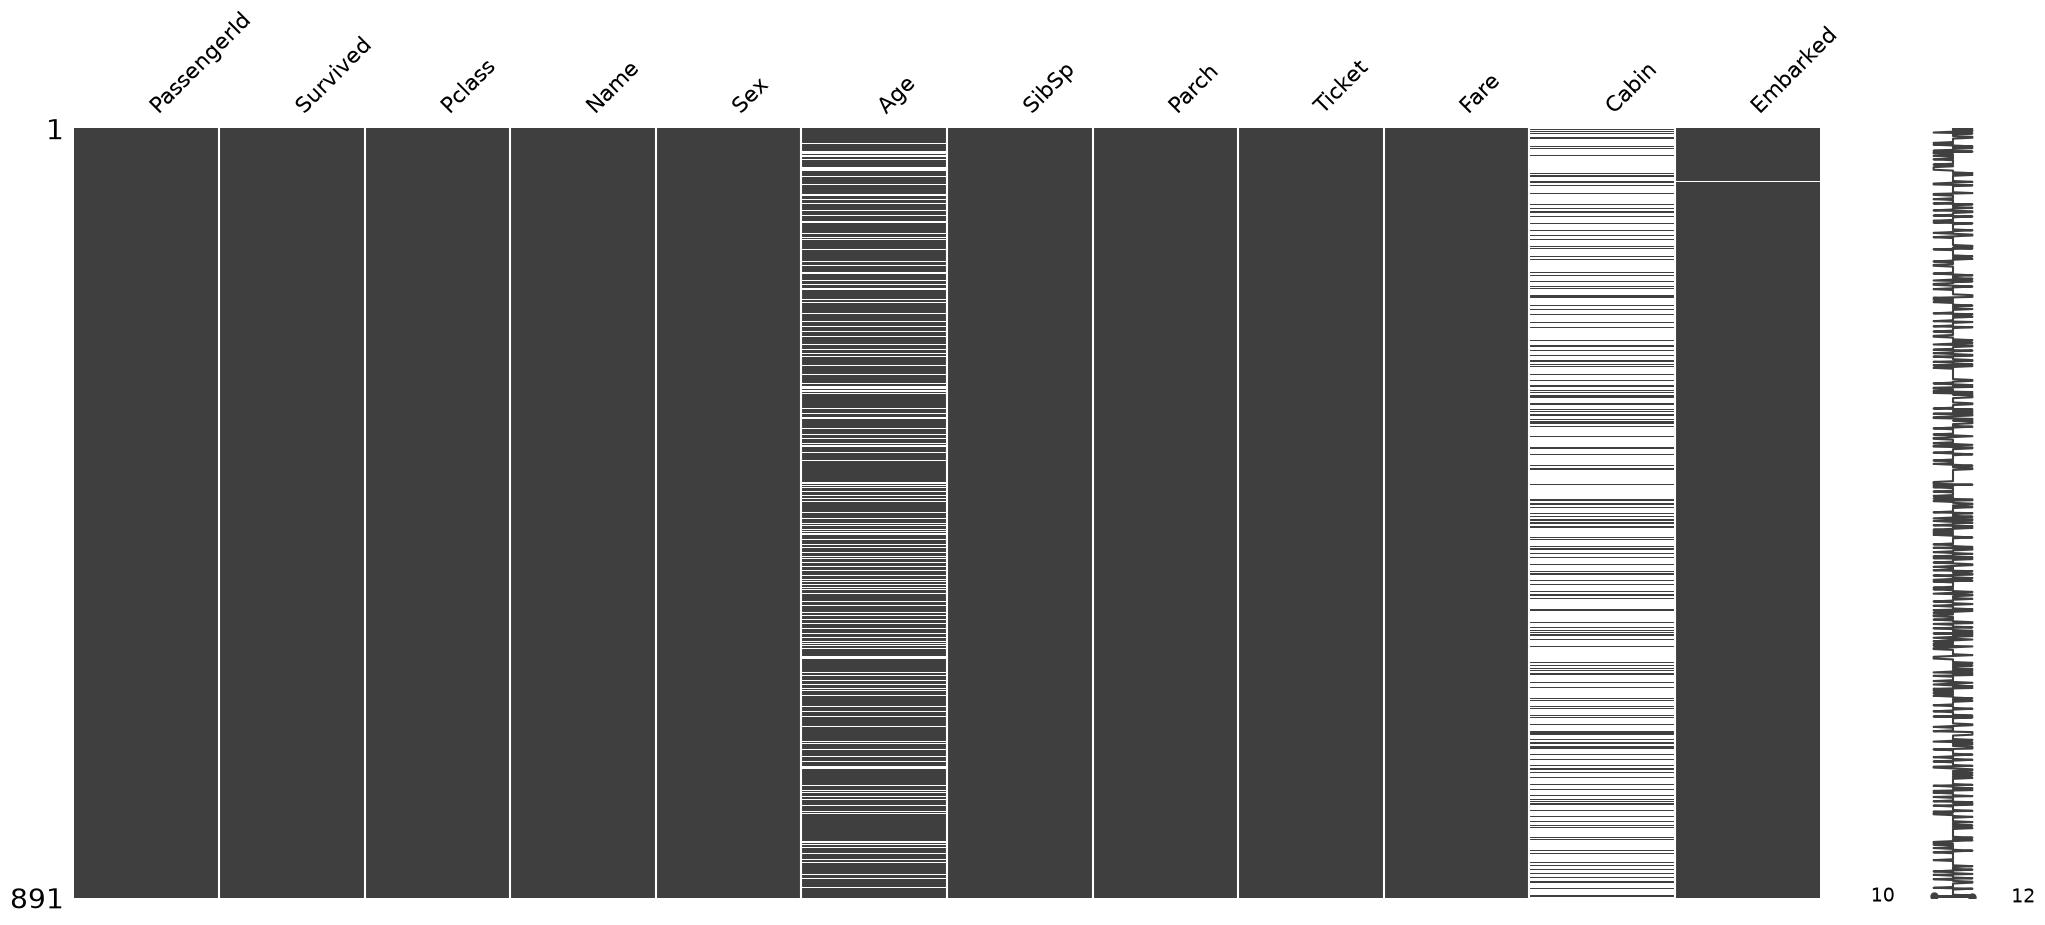

In [9]:
msno.matrix(df)
plt.show()

### Definimos la variable objetivo de estudio en esta caso la DataBase es sobre los supervivientes del accidente del titanic por lo tanto selecionamos el atributo Edad para saber la edad de las personas que estuvieron en el incidente

In [10]:
df["Age"].fillna(
    df["Age"].median(),
    inplace=True
)

C:\Users\eduar\AppData\Local\Temp\ipykernel_29208\4028288069.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

### a su vez igual estudiaremos el atributo embarcado o no embarcado de los pasajeros 

In [11]:
df["Embarked"].fillna(
    df["Embarked"].mode()[0],
    inplace=True
)

C:\Users\eduar\AppData\Local\Temp\ipykernel_29208\581150554.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Embarked"].fillna(


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

### Una vez teniendo los atributos a estudiar hacemos uso otra vez de la funcion .isnull para verificar los datos vacios de ambas instancias 

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### en este caso decimos que solo queremos saber los pasajeros que eran del sexo femenino 

In [13]:
df[df["Sex"]=="female"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


### y definimos si 1=supervivio , queremos saber solo los que si sobrevivieron

In [14]:
df[df["Survived"]==1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


### y de nuestra muestra recapitulamos un total de 50 muestras aleatorias de toda nuestra data set

In [15]:
muestra = df.sample(
    n=50,
    random_state=42
)

muestra

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S
208,209,1,3,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,NaN,Q
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S


### y hacemos q nos describa la muestra 

In [16]:
muestra.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,50.000000,50.000000,50.000000,39.000000,50.000000,50.000000,50.000000
mean,437.140000,0.360000,2.400000,26.128205,0.420000,0.320000,21.999916
std,281.293732,0.484873,0.857143,11.564873,0.835195,0.712569,21.757122
min,24.000000,0.000000,1.000000,4.000000,0.000000,0.000000,7.045800
25%,200.500000,0.000000,2.000000,19.000000,0.000000,0.000000,7.895800
50%,380.000000,0.000000,3.000000,24.000000,0.000000,0.000000,13.000000
75%,693.500000,1.000000,3.000000,31.000000,0.750000,0.000000,27.900000
max,887.000000,1.000000,3.000000,58.000000,3.000000,3.000000,113.275000


In [17]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


### Hacemos que nos genere un minimo maximo en una escala sobre la edad y la frecuencia


In [20]:
scaler = MinMaxScaler()

df[["Age","Fare"]] = scaler.fit_transform(
    df[["Age","Fare"]]
)

In [21]:
df[["Age","Fare"]].head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


### y graficamos lo correspondiente

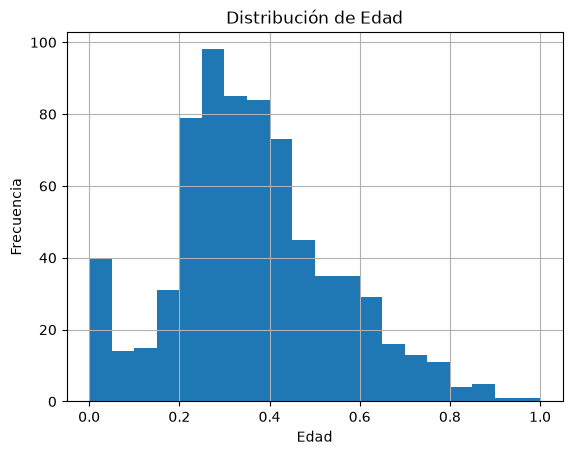

In [22]:
df["Age"].hist(
    bins=20
)

plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

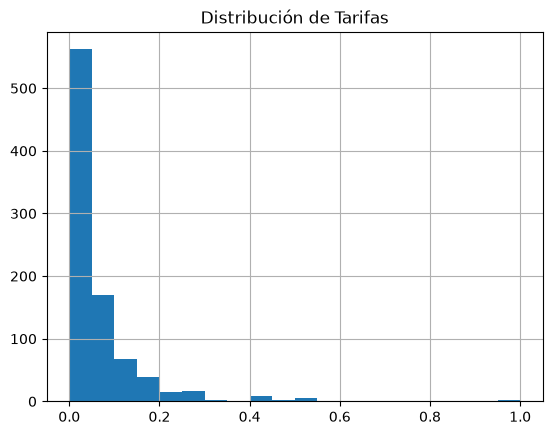

In [23]:
df["Fare"].hist(
    bins=20
)

plt.title("Distribución de Tarifas")
plt.show()

In [24]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [25]:
datos = df[
    ["Age", "Fare", "Sex", "Pclass"]
]

### volvemos a generar los valores nulos o vacios 

In [26]:
datos.isnull().sum()

Age       177
Fare        0
Sex       891
Pclass      0
dtype: int64

### y imprimimos los valores y los tipos de dato que tienen esos datos 

In [27]:
print("TIPOS DE DATOS")
print(datos.dtypes)

print("\nVALORES NULOS")
print(datos.isnull().sum())

print("\nPRIMEROS REGISTROS")
print(datos.head())

TIPOS DE DATOS
Age       float64
Fare      float64
Sex       float64
Pclass      int64
dtype: object

VALORES NULOS
Age       177
Fare        0
Sex       891
Pclass      0
dtype: int64

PRIMEROS REGISTROS
        Age      Fare  Sex  Pclass
0  0.271174  0.014151  NaN       3
1  0.472229  0.139136  NaN       1
2  0.321438  0.015469  NaN       3
3  0.434531  0.103644  NaN       1
4  0.434531  0.015713  NaN       3


In [28]:
datos.iloc[:10]

,Age,Fare,Sex,Pclass
0,0.271174,0.014151,NaN,3
1,0.472229,0.139136,NaN,1
2,0.321438,0.015469,NaN,3
3,0.434531,0.103644,NaN,1
4,0.434531,0.015713,NaN,3
5,NaN,0.016510,NaN,3
6,0.673285,0.101229,NaN,1
7,0.019854,0.041136,NaN,3
8,0.334004,0.021731,NaN,3
9,0.170646,0.058694,NaN,2


In [33]:
df = pd.read_csv("train.csv")

In [34]:
df["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [35]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [36]:
df["Sex"].unique()

array([0, 1])

In [38]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

In [39]:
df[["Age","Sex"]].isnull().sum()

Age    0
Sex    0
dtype: int64

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

datos = df[
    ["Age",
     "Fare",
     "Sex",
     "Pclass"]
]

similitud = cosine_similarity(
    datos.iloc[:10]
)

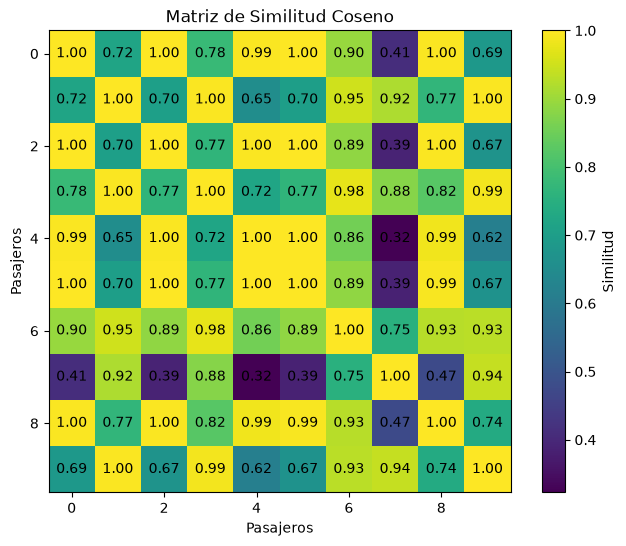

In [44]:
plt.figure(figsize=(8,6))

plt.imshow(similitud)

plt.colorbar(label="Similitud")

for i in range(similitud.shape[0]):
    for j in range(similitud.shape[1]):
        plt.text(
            j,
            i,
            f"{similitud[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de Similitud Coseno")
plt.xlabel("Pasajeros")
plt.ylabel("Pasajeros")

plt.show()